# KL divergence and f-Divergence

## Motivation and definition

Let's consider as KL divergence and f-Divergence in the context of AI/ML. In AI/ML often we have a real world probability distribution $P(x_i)$ that we are modelling with $Q(x_i)$. A concrete example will be, when we are training LLMs to model human language. In this example, $P(x_i)$ is human language and $Q(x_i)$ is the LLM.

Can we measure the difference between the two distribution?

There are different metrics that we can use, but KL divergence is one of most popular one if not the most important. KL divergence could be thought of how many number of bytes on average more does it take to encode the information in $Q(x_i)$. Concretely, it is defined as:

$$D_{KL}(P || Q) := -p(x_i)\log q(x_i) + p(x_i)\log p(x_i)$$

In this article, I will use Einstein notation and work with discrete probability distribution to keep the maths simple. The same argument can be applied to continuous probability distribution as well.

In reality, this expression is almost impossible to compute directly. Often we have control over $Q(x_i)$ not $P(x_i)$, for example, we can do agent rollout with our LLM $Q(x_i)$ not with the real human language $P(x_i)$. Therefore, often it is better to write this expression as:

$$D_{KL}(P || Q) := q(x_i) \frac{p(x_i)}{q(x_i)}\log \frac{p(x_i)}{q(x_i)} = \mathbb{E}_Q [r\log r]$$

where we introduced a shorthand notation $r:=p/q$. This is where we can link to f-Divergence.

$$D_{f}(P||Q) := \mathbb{E}_Q\left[f(r)\right],$$

where $f$ is convex and $f(1)=0$. 

f-Divergence enjoys a great deal of nice properties, for example f-Divergence is always greater or equal to zero. This makes it suitable to use as a loss function in training. To close out this section, we can plot the KL-divergence f function which is $r\log r$ to confirm it is indeed convex and $f(1) = 0$:

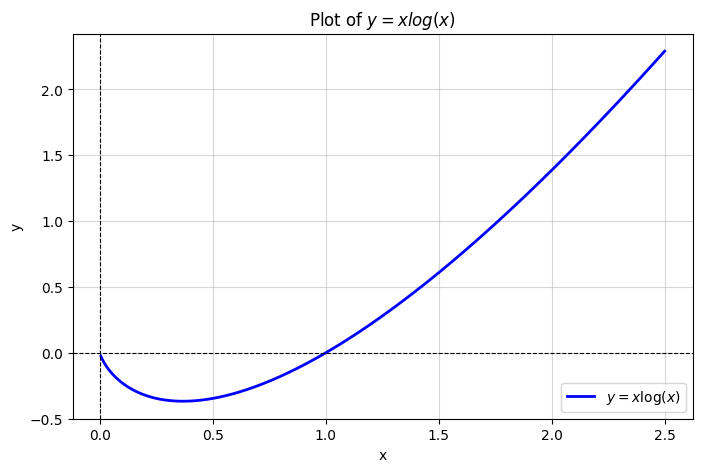

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate x values from -1 to 5
# We use 500 points for a smooth curve
x = np.linspace(0, 2.5, 500)

# 2. Calculate y values
# We use np.errstate to suppress the expected warnings for x <= 0
with np.errstate(divide='ignore', invalid='ignore'):
    y = x * np.log(x) 

# 3. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y = x \log(x)$', color='blue', linewidth=2)

# 4. Add styling for readability
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # x-axis
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') # y-axis
plt.title('Plot of $y = x log(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.5)
plt.legend()

# 5. Display the plot
plt.show()

## Forward and reverse KL

Mathematically $P(x)$ and $Q(x)$ are probability distribution and there is no "previlege" between the two. However, in AI/ML $P(x)$ is the real distribution and $Q(x)$ is the model distribution, or $P(x)$ is the teacher model and $Q(x)$ is the student model. We implicitly give $P(x)$ the previlege in AI/ML. This leads to the notion of forward KL and reverse KL divergence. Forward KL is the KL divergence that is defined in statistics, and reverse KL is the arguements reversed. Concretely:

$$
\begin{aligned}
D_{KL-\text{forward}}(P||Q) & := \mathbb{E}_Q [r\log r] \\
D_{KL-\text{reverse}}(Q||P) & := \mathbb{E}_Q [-\log r]
\end{aligned}
$$

We can check that reverse KL f is also convex, and satisifies $f(1)=0$:

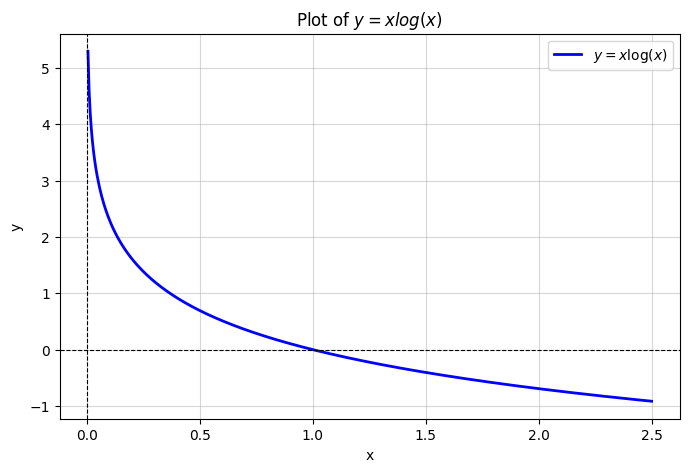

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate x values from -1 to 5
# We use 500 points for a smooth curve
x = np.linspace(0, 2.5, 500)

# 2. Calculate y values
# We use np.errstate to suppress the expected warnings for x <= 0
with np.errstate(divide='ignore', invalid='ignore'):
    y = - np.log(x) 

# 3. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y = x \log(x)$', color='blue', linewidth=2)

# 4. Add styling for readability
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # x-axis
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') # y-axis
plt.title('Plot of $y = x log(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.5)
plt.legend()

# 5. Display the plot
plt.show()

Note that $\lim_{r\rightarrow 0} -\log r \rightarrow \infty$. This leads to behaviours that people call mode seeking. If we were to use reverse KL as our loss function, the model $Q(x)$ does everything in its power to avoid making $r(x) = p(x) / q(x)$ become zero. In other words, when $p(x)$ small $q(x)$ is also small, which leads to the distribution to avoid spreading out wide, and avoid assigning any probability to where $p(x)$ is small.

To contrast with this behaviour, often people say training on forward KL is mean seeking where $Q(x)$ will spread across to cover $P(x)$ as much as possible.

## Estimating forward and reverse KL

In real life, often we cannot compute the probabiltiy distribution exactly, but only a sample of it. How can we estimate forward and reverse KL with just a sample of the distribution? Recall that the f-function for forward and reverse KL are:

$$
\begin{aligned}
f_{\text{forward}}(r) & := r\log r \\
f_{\text{reverse}}(r) & := -\log r
\end{aligned}
$$

Computing these functions directly and computing the expectation will eventually give us the correct answer, but note that the functions produce negative answers, while KL divergence is always non-negative. In other words, these function estimate is not biased but have high variance. A classic solution to adjusting the variance is to add a variable that eventually will disappear away but can correct the early behaviour with small samples. In this case, we want to correct the behaviour that if we use the f-functions directly, it can produce negative numbers. We have one natural quantity that will disappear as we sample more and more, namely $r-1$, we can add this to the f-functions with a variable $\lambda$:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r + \lambda_1 (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + \lambda_2 (r - 1)
\end{aligned}
$$

Now the task is to pick $\lambda_1$ and $\lambda_2$ so that the modified $\tilde{f}$ function will always be positive. We can eyeball the solution from looking at the graph or taking the derivative to find $\lambda$ like Langrange multiplier method. In our case, the solution is almost readable from the graph:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r - (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + (r - 1)
\end{aligned}
$$

Here is an explicit computation to compare $f$ and $\tilde{f}$:

In [14]:
import torch.distributions as dis

p = dis.Normal(loc=0, scale=1)
q = dis.Normal(loc=0.1, scale=1)
x = q.sample(sample_shape=(10_000_000,))

true_kl = dis.kl_divergence(p, q)
logr = p.log_prob(x) - q.log_prob(x)

forward = logr.exp() * logr - (logr.exp() - 1)
reverse = -logr + (logr.exp() - 1)

print(f"{true_kl=}")
print(f"{forward.mean()=} {forward.std()=}")
print(f"{reverse.mean()=} {reverse.std()=}")

true_kl=tensor(0.0050)
forward.mean()=tensor(0.0050) forward.std()=tensor(0.0072)
reverse.mean()=tensor(0.0050) reverse.std()=tensor(0.0071)
